# Response Opportunity Analysis

The response set contained one L1 transfer option, one correct option, and two L2 options. Because L2 responses occupied twice the response space of the other categories, observed proportions may be more informative when interpreted relative to response opportunity.

### Expected Response under random selection
- L1_transfer: .25
- L2_other: .50
- correct: .25

Import libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Overall Subgroup:
1. Observed Proportions
2. Deviation from baseline
3. Summary metrics
4. Conversion Efficiency

Read data

In [58]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

1. Observed Proportions

In [59]:
proportions = pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical["Agent"], subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.317073  0.341463   
                  1     Yes                          0.500000  0.083333   
goal_non_frequent 0     No                           0.500000  0.214286   
                  1     No                           0.666667  0.041667   
no_goal           0     Yes                          0.575000  0.200000   
                  1     Yes                          0.458333  0.166667   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.341463  
                  1     Yes                       0.416667  
goal_non_frequent 0     No                        0.285714  
                  1     No                        0.291667  
no_goal           0     Yes                       0.225000  
                  1     Yes                       0.375000

2. Deviation from baseline

In [60]:
baseline = pd.Series({
    "L1_transfer": 0.25,
    "L2_other": 0.50,
    "correct": 0.25
})

deviation = proportions - baseline
deviation

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.067073 -0.158537   
                  1     Yes                          0.250000 -0.416667   
goal_non_frequent 0     No                           0.250000 -0.285714   
                  1     No                           0.416667 -0.458333   
no_goal           0     Yes                          0.325000 -0.300000   
                  1     Yes                          0.208333 -0.333333   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.091463  
                  1     Yes                       0.166667  
goal_non_frequent 0     No                        0.035714  
                  1     No                        0.041667  
no_goal           0     Yes                      -0.025000  
                  1     Yes                       0.125000

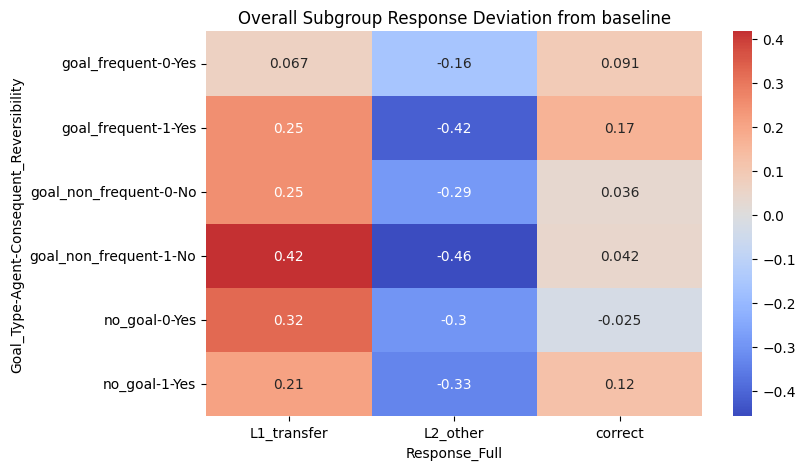

In [61]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    deviation,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Overall Subgroup Response Deviation from baseline")
plt.show()

The theoretical subgroup does not appear to be characterized by enhanced target-like responding per se. Rather, it appears to be characterized by systematic suppression of L2-based interpretations. What differs across conditions is how those “freed” responses are redistributed between L1-transfer and target-like interpretations.

What it seems is that goal structure determines the direction of redistribution away from L2 and agency modulates the strencgth of the redistribution. 

- goal_frequent conditions repeteadly look healthier
- goal_non_frequent condtions repeatedly look more L1_transfer oriented.
- agency often strengthens the tendency rather than creating a new one. 

3. Summary Metrics:
- L2_suppression
- L1_shift
- Correct_gain

In [62]:
# L2 suppression = baseline L2_other - observed L2_other

L2_suppression = baseline["L2_other"] - proportions["L2_other"]
L2_suppression

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.158537
                   1      Yes                         0.416667
goal_non_frequent  0      No                          0.285714
                   1      No                          0.458333
no_goal            0      Yes                         0.300000
                   1      Yes                         0.333333
Name: L2_other, dtype: float64

In [63]:
# Correctness gain = observed correct - baseline correct

correct_gain = proportions["correct"] - baseline["correct"]
correct_gain

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.091463
                   1      Yes                         0.166667
goal_non_frequent  0      No                          0.035714
                   1      No                          0.041667
no_goal            0      Yes                        -0.025000
                   1      Yes                         0.125000
Name: correct, dtype: float64

In [64]:
# L1_shift = observed L1_transfer - baseline L1_transfer

L1_shift = proportions["L1_transfer"] - baseline["L1_transfer"]
L1_shift

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.067073
                   1      Yes                         0.250000
goal_non_frequent  0      No                          0.250000
                   1      No                          0.416667
no_goal            0      Yes                         0.325000
                   1      Yes                         0.208333
Name: L1_transfer, dtype: float64

4. Conversion efficiency

In [65]:
# Conversion efficiency = Correctness gain / L2 suppression
conversion_efficiency = correct_gain/ L2_suppression
conversion_efficiency

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.576923
                   1      Yes                         0.400000
goal_non_frequent  0      No                          0.125000
                   1      No                          0.090909
no_goal            0      Yes                        -0.083333
                   1      Yes                         0.375000
dtype: float64

In [66]:
summary_metrics = pd.DataFrame({
    "L2_suppression": L2_suppression,
    "L1_shift": L1_shift,
    "Correct_gain": correct_gain, 
    "Conversion_efficiency": conversion_efficiency
})

summary_metrics

L2_suppression  L1_shift  \
Goal_Type         Agent Consequent_Reversibility                             
goal_frequent     0     Yes                             0.158537  0.067073   
                  1     Yes                             0.416667  0.250000   
goal_non_frequent 0     No                              0.285714  0.250000   
                  1     No                              0.458333  0.416667   
no_goal           0     Yes                             0.300000  0.325000   
                  1     Yes                             0.333333  0.208333   

                                                  Correct_gain  \
Goal_Type         Agent Consequent_Reversibility                 
goal_frequent     0     Yes                           0.091463   
                  1     Yes                           0.166667   
goal_non_frequent 0     No                            0.035714   
                  1     No                            0.041667   
no_goal           0     Yes                          -0.025000   
                  1     Yes                           0.125000   

                                                  Conversion_efficiency  
Goal_Type         Agent Consequent_Reversibility                         
goal_frequent     0     Yes                                    0.576923  
                  1     Yes                                    0.400000  
goal_non_frequent 0     No                                     0.125000  
                  1     No                                     0.090909  
no_goal           0     Yes                                   -0.083333  
                  1     Yes                                    0.375000

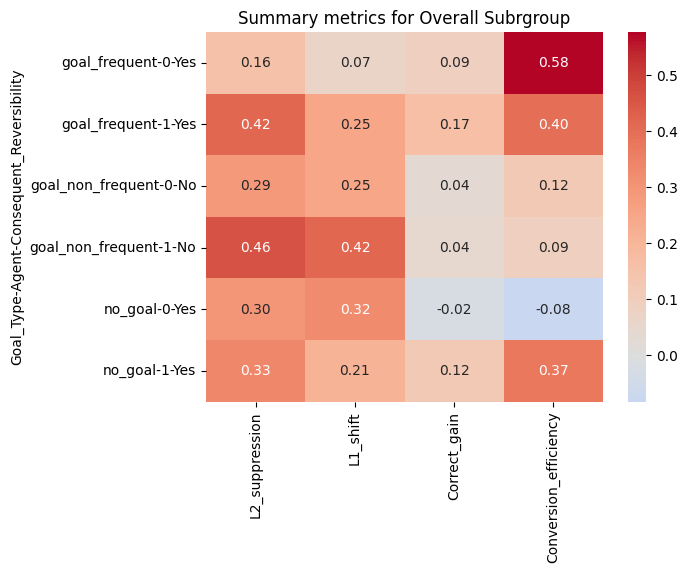

In [67]:
sns.heatmap(
    summary_metrics,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Summary metrics for Overall Subrgroup")
plt.show()

Although goal_non_frequent + agentive conditions produced the strongest suppression of L2 responses, most of these redistributed responses shifted toward L1 transfer rather than correctness. In contrast, goal_frequent conditions exhibited substantially greater conversion efficiency, indicating that a larger proportion of suppressed L2 responses were converted into correct interpretations. Thus, response redistribution appears to depend not only on the magnitude of L2 suppression but also on the destination of the redistributed responses.

## Actors Subgroup:
1. Observed Proportions
2. Deviation from baseline
3. Summary metrics
4. Conversion Efficiency

Read data

In [68]:
subgroup_actors = subgroup_theoretical[subgroup_theoretical["Focus"] == "I"].copy()

1. Observed proportions

In [69]:
proportions = pd.crosstab(
    [subgroup_actors["Goal_Type"], subgroup_actors["Agent"], subgroup_actors["Consequent_Reversibility"]],
    subgroup_actors["Response_Full"],
    normalize="index"
)

proportions

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.260870  0.347826   
                  1     Yes                          0.437500  0.125000   
goal_non_frequent 0     No                           0.291667  0.333333   
                  1     No                           0.687500  0.062500   
no_goal           0     Yes                          0.590909  0.136364   
                  1     Yes                          0.562500  0.125000   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.391304  
                  1     Yes                       0.437500  
goal_non_frequent 0     No                        0.375000  
                  1     No                        0.250000  
no_goal           0     Yes                       0.272727  
                  1     Yes                       0.312500

2. Deviation from baseline

In [70]:
baseline = pd.Series({
    "L1_transfer": 0.25,
    "L2_other": 0.50,
    "correct": 0.25
})

deviation = proportions - baseline
deviation

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.010870 -0.152174   
                  1     Yes                          0.187500 -0.375000   
goal_non_frequent 0     No                           0.041667 -0.166667   
                  1     No                           0.437500 -0.437500   
no_goal           0     Yes                          0.340909 -0.363636   
                  1     Yes                          0.312500 -0.375000   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.141304  
                  1     Yes                       0.187500  
goal_non_frequent 0     No                        0.125000  
                  1     No                        0.000000  
no_goal           0     Yes                       0.022727  
                  1     Yes                       0.062500

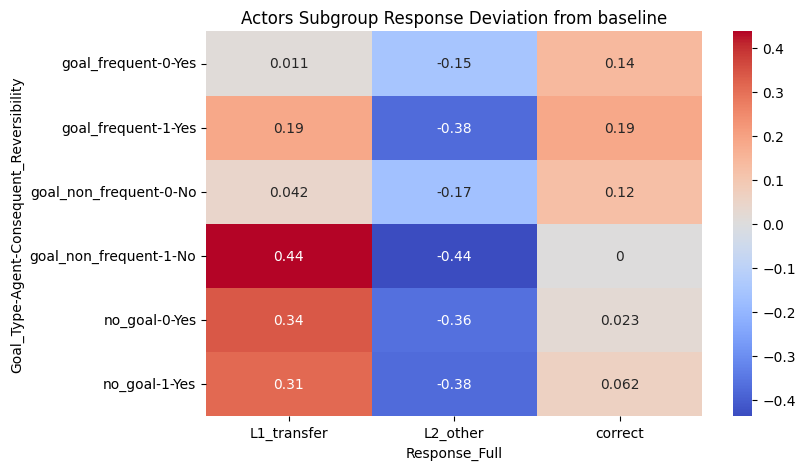

In [71]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    deviation,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Actors Subgroup Response Deviation from baseline")
plt.show()

3. Summary Metrics:
- L2 suppression
- Correctness gain
- L1 shift

In [72]:
# L2 suppression = baseline L2_other - observed L2_other

L2_suppression = baseline["L2_other"] - proportions["L2_other"]
L2_suppression

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.152174
                   1      Yes                         0.375000
goal_non_frequent  0      No                          0.166667
                   1      No                          0.437500
no_goal            0      Yes                         0.363636
                   1      Yes                         0.375000
Name: L2_other, dtype: float64

In [73]:
# Correctness gain = observed correct - baseline correct

correct_gain = proportions["correct"] - baseline["correct"]
correct_gain

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.141304
                   1      Yes                         0.187500
goal_non_frequent  0      No                          0.125000
                   1      No                          0.000000
no_goal            0      Yes                         0.022727
                   1      Yes                         0.062500
Name: correct, dtype: float64

In [74]:
# L1_shift = observed L1_transfer - baseline L1_transfer

L1_shift = proportions["L1_transfer"] - baseline["L1_transfer"]
L1_shift

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.010870
                   1      Yes                         0.187500
goal_non_frequent  0      No                          0.041667
                   1      No                          0.437500
no_goal            0      Yes                         0.340909
                   1      Yes                         0.312500
Name: L1_transfer, dtype: float64

4. Conversion efficiency

In [75]:
# Conversion efficiency = Correctness gain / L2 suppression
conversion_efficiency = correct_gain/ L2_suppression
conversion_efficiency

Goal_Type          Agent  Consequent_Reversibility
goal_frequent      0      Yes                         0.928571
                   1      Yes                         0.500000
goal_non_frequent  0      No                          0.750000
                   1      No                          0.000000
no_goal            0      Yes                         0.062500
                   1      Yes                         0.166667
dtype: float64

In [76]:
summary_metrics = pd.DataFrame({
    "L2_suppression": L2_suppression,
    "L1_shift": L1_shift,
    "Correct_gain": correct_gain, 
    "Conversion_efficiency": conversion_efficiency
})

summary_metrics

L2_suppression  L1_shift  \
Goal_Type         Agent Consequent_Reversibility                             
goal_frequent     0     Yes                             0.152174  0.010870   
                  1     Yes                             0.375000  0.187500   
goal_non_frequent 0     No                              0.166667  0.041667   
                  1     No                              0.437500  0.437500   
no_goal           0     Yes                             0.363636  0.340909   
                  1     Yes                             0.375000  0.312500   

                                                  Correct_gain  \
Goal_Type         Agent Consequent_Reversibility                 
goal_frequent     0     Yes                           0.141304   
                  1     Yes                           0.187500   
goal_non_frequent 0     No                            0.125000   
                  1     No                            0.000000   
no_goal           0     Yes                           0.022727   
                  1     Yes                           0.062500   

                                                  Conversion_efficiency  
Goal_Type         Agent Consequent_Reversibility                         
goal_frequent     0     Yes                                    0.928571  
                  1     Yes                                    0.500000  
goal_non_frequent 0     No                                     0.750000  
                  1     No                                     0.000000  
no_goal           0     Yes                                    0.062500  
                  1     Yes                                    0.166667

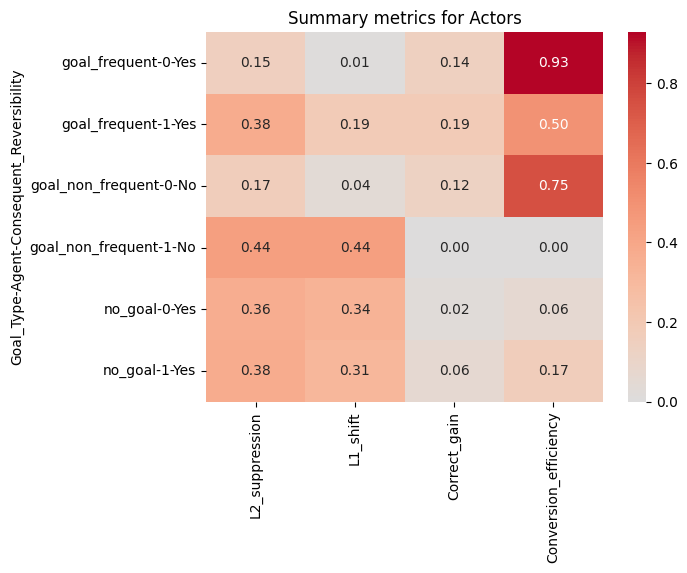

In [77]:
sns.heatmap(
    summary_metrics,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Summary metrics for Actors")
plt.show()

Goal-frequent and goal-non-frequent patterns are remarkably similar when agency is absent. The major divergence emerges when agency is introduced, suggesting that agency activates L1-based interpretations. Goal-frequent structures partially resist this pull and retain gains in correctness, whereas goal-non-frequent structures redirect nearly all suppressed L2 responses toward L1-transfer interpretations.